In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np

import matplotlib.pyplot as plt

1. İlk önce her karaktere karşılık gelen 8 bitlik karakter tanımlarını ayarlamak gerek. (İlk Braille Alfabesi'nden etkilendim)
2. Sonrada bir temel kelime uzunluğu belirleyip, sanırım 70 karakterini belirleyeceğim. 
3. Her kelimeyinin karşılığı olan 8 bitlik karakteri alacağız. 
4. Bunları bir matrise çevireceğin. 
5. Bu matrise positional encoding'i uygylayacağız ve elimizde özellik matrisi olacak.


In [8]:
max_seq_len = 70 # Maximum kelime uzunluğu
bit_depth = 8 # Her karakteri temsil eden dizinin uzunluğu.
exam_seq = "Merhaba" # Örnek kelime.


In [ ]:
# karakterlerin 8 bitlik tanımlarının yapılması
vocab = (
     ['<PAD>',   # padding (sequence equalization)
     '<UNK>',   # bilinmeyen karakter
     '<BOS>',   # beginning of sentence
     '<EOS>',   # end of sentence
     '<MASK>',  # masking (BERT tarzı)
     ' '] +      # boşluk (space)
    
    list('abcçdefgğhıijklmnoöprsştuüvyz') +
    list('ABCÇDEFGĞHIİJKLMNOÖPRSŞTUÜVYZ') +
    list('0123456789') +
    
    ['.',',',';',':','?','!','"',"'",'(',')','[',']','{','}','-','–','—','…','/','\\','|'] +
    
    ['\n']
)

char_dic = {}
for i in range(0, len(vocab) - 1):
    bits = [int(b) for b in format(i, '08b')]
    print(f"{i} -> {bits}")
    char_dic[vocab[i]] = bits


char_dic


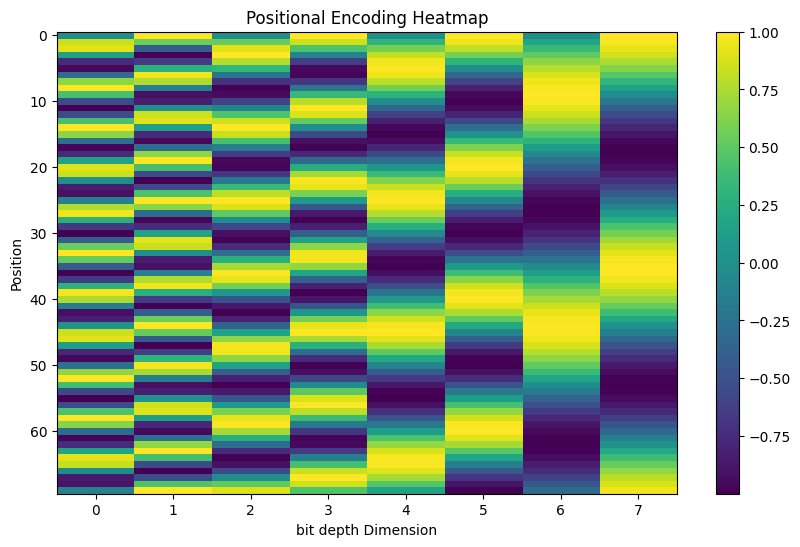

In [12]:
def plot_positional_encoding(pe):
    """
    Positional encoding matrisini görselleştirir
    """
    plt.figure(figsize=(10, 6))
    plt.imshow(pe, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("Positional Encoding Heatmap")
    plt.xlabel("bit depth Dimension")
    plt.ylabel("Position")
    plt.show()

def get_angle(pos, i, d_model):
    """
    Pozisyon ve boyut indeksine göre açı değerini hesaplar
    """
    return pos / (10 ** ((2 * (i // 2)) / d_model))


def positional_encoding_matrix(vocab_len, bit_depth):
    """
    Tüm positional encoding matrisini oluşturur
    """
    PE = np.ones((vocab_len, bit_depth))

    for pos in range(vocab_len):
        for i in range(bit_depth):
            angle = get_angle(pos, i, bit_depth)
            if i % 2 == 0:
                PE[pos, i] = np.sin(angle)
            else:
                PE[pos, i] = np.cos(angle)

    return PE

positional_information = positional_encoding_matrix(max_seq_len, bit_depth)

plot_positional_encoding(positional_information)



In [ ]:
# 70 x 8 boyutunda kelime matrisi olacak elimde. 
# Yani 560 boyutunda bir girdi alan bir şey lazım. 
# çıktı olarak dil modellerinin ihtiyacı olan 512'yi tercih edebilirim.

class TestModel(nn.Module):
    def __init__(self):
        self.linear1 = nn.Linear(560, 1024)
        self.linear2 = nn.Linear(1024, 1024)
        self.linear3 = nn.Linear(1024, 512)
        self.relu = nn.ReLU()
        pass

    def forward(self, vocab_matrix):
        arr = np.asarray(vocab_matrix).reshape(-1)

        x = self.linear1(arr)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        x = self.relu(x)

        return x

In [ ]:
# Modeli eğitme aşamsı

model = TestModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X = torch.rand(64, 100) # 100 tane özellikli 64 örnek. Aslında bizim senaryoda 70 * 8 tane özellik olacak. 
y = torch.randint(0, 10, (64,))  # 10 sınıf


epochs = 10

for epoch in range(epochs):

    model.train() # Modeli eğitime hazırlıyor.

    outputs = model(X)

    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch + 1}, Loss {loss.item():.4f}")



